# Scenario 3: Rogue Redirection and Exfiltration Analysis

This notebook reviews the exfiltration capture. It tracks the normal phase, the attacker trigger at $t=300$, and the camera's redirect to the rogue cloud.

**Topology:**
* Camera: `10.0.0.1`
* Thermostat: `10.0.0.2`
* Attacker: `10.0.0.3`
* Gateway: `10.0.0.254`
* Rogue Gateway: `203.0.113.1`
* Rogue Cloud: `203.0.113.5`
* Duration: 20 minutes

In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from zat.log_to_dataframe import LogToDataFrame

# Set academic plotting style for LaTeX embedding
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.family": "serif",
    "axes.labelsize": 12,
    "font.size": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 300
})

# Define paths
LOG_DIR = "../../zeek_logs/scenario3_logs/"  # Adjust relative path if needed
OUTPUT_DIR = "../../figures/scenario3/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Scenario constants
PHASE1_SECONDS = 300
EXFIL_TARGET = "203.0.113.5"
ROGUE_GW = "203.0.113.1"
LEGIT_DOMAIN = "api.smartcamera.local"
MALICIOUS_DOMAIN = "c2.malicious-exfil.com"


def save_figure(fig, filename_base, output_dir=OUTPUT_DIR):
    pdf_path = os.path.join(output_dir, f"{filename_base}.pdf")
    png_path = os.path.join(output_dir, f"{filename_base}.png")
    fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
    fig.savefig(png_path, format="png", bbox_inches="tight", dpi=300)
    print(f"Saved figure: {pdf_path} and {png_path}")


def format_elapsed_mmss(value, _):
    total_seconds = max(0, int(round(value * 60)))
    minutes, seconds = divmod(total_seconds, 60)
    return f"{minutes:02d}:{seconds:02d}"

## Data Ingestion & Preprocessing
We load the Zeek logs, clean the data, and keep only traffic from the target devices and gateway.

In [5]:
# Initialize ZAT parser
log_to_df = LogToDataFrame()

# Ingest Zeek Logs
conn_df = log_to_df.create_dataframe(os.path.join(LOG_DIR, 'conn.log'))
dns_df = log_to_df.create_dataframe(os.path.join(LOG_DIR, 'dns.log'))
ntp_df = log_to_df.create_dataframe(os.path.join(LOG_DIR, 'ntp.log'))
packet_filter_df = log_to_df.create_dataframe(os.path.join(LOG_DIR, 'packet_filter.log'))

# Deduplicate packets caused by Mininet capturing on 'any' interface
conn_df = conn_df.drop_duplicates(subset=['uid'], keep='first')
dns_df = dns_df.drop_duplicates(subset=['uid'], keep='first')
ntp_df = ntp_df.drop_duplicates(subset=['uid'], keep='first')

# Preprocessing: Ensure timestamps are timezone-naive for easier math
if conn_df.index.tz is not None:
    conn_df.index = conn_df.index.tz_localize(None)
if dns_df.index.tz is not None:
    dns_df.index = dns_df.index.tz_localize(None)
if ntp_df.index.tz is not None:
    ntp_df.index = ntp_df.index.tz_localize(None)
if packet_filter_df.index.tz is not None:
    packet_filter_df.index = packet_filter_df.index.tz_localize(None)

# Define our forensic scope
target_ips = ['10.0.0.1', '10.0.0.2', '10.0.0.3', '10.0.0.254', '203.0.113.1', '203.0.113.5']

# Filter logs to ensure we capture any conversation touching our target architecture
conn_df = conn_df[conn_df['id.orig_h'].isin(target_ips) | conn_df['id.resp_h'].isin(target_ips)]
dns_df = dns_df[dns_df['id.orig_h'].isin(target_ips) | dns_df['id.resp_h'].isin(target_ips)]
ntp_df = ntp_df[ntp_df['id.orig_h'].isin(target_ips) | ntp_df['id.resp_h'].isin(target_ips)]

# packet_filter.log is Zeek capture metadata; keep it loaded for completeness, but it is not used for behavioral analysis.


## Macro Statistics and Phase Check

This section validates that normal traffic appears early and that exfiltration activity starts after the trigger at $t=300$.

* Phase 1: camera UDP stream to the gateway + normal DNS.
* Phase 2: attacker trigger + UDP exfiltration to the rogue cloud + C2 DNS lookups.

In [6]:
# ==========================================
# MACRO STATS & PHASE VALIDATION
# ==========================================
import pandas as pd

camera_ip = "10.0.0.1"
thermostat_ip = "10.0.0.2"
attacker_ip = "10.0.0.3"
gateway_ip = "10.0.0.254"

# Get total connections tracked by Zeek
total_conns = len(conn_df)

# Calculate empirical capture duration
capture_duration = (conn_df.index.max() - conn_df.index.min()).total_seconds()

# Infrastructure Services
dns_conns = conn_df[(conn_df['id.resp_p'] == 53) & (conn_df['proto'] == 'udp')]
entropy_ntp_conns = conn_df[(conn_df['id.resp_p'] == 123) & (conn_df['proto'] == 'udp')]
ntp_conns = entropy_ntp_conns

# Smart Camera (10.0.0.1)
cam_udp_legit = conn_df[
    (conn_df['id.orig_h'] == camera_ip) &
    (conn_df['id.resp_h'] == gateway_ip) &
    (conn_df['id.resp_p'] == 50005) &
    (conn_df['proto'] == 'udp')
]
cam_udp_exfil = conn_df[
    (conn_df['id.orig_h'] == camera_ip) &
    (conn_df['id.resp_h'] == EXFIL_TARGET) &
    (conn_df['id.resp_p'] == 443) &
    (conn_df['proto'] == 'udp')
]
cam_tls = conn_df[
    (conn_df['id.orig_h'] == camera_ip) &
    (conn_df['id.resp_p'] == 443) &
    (conn_df['proto'] == 'tcp')
]

# Smart Thermostat (10.0.0.2)
therm_mqtt = conn_df[(conn_df['id.orig_h'] == thermostat_ip) & (conn_df['id.resp_p'] == 8883) & (conn_df['proto'] == 'tcp')]
therm_keepalive = therm_mqtt[therm_mqtt['orig_bytes'].fillna(0) < 20]
therm_payload = therm_mqtt[therm_mqtt['orig_bytes'].fillna(0) >= 20]

# Attacker trigger (10.0.0.3 -> 10.0.0.1:443)
attacker_trigger = conn_df[
    (conn_df['id.orig_h'] == attacker_ip) &
    (conn_df['id.resp_h'] == camera_ip) &
    (conn_df['id.resp_p'] == 443) &
    (conn_df['proto'] == 'tcp')
]

# Supplemental Zeek evidence for the exfil path (optional weird.log)
weird_path = os.path.join(LOG_DIR, 'weird.log')
if os.path.exists(weird_path):
    weird_df = log_to_df.create_dataframe(weird_path)
    if weird_df.index.tz is not None:
        weird_df.index = weird_df.index.tz_localize(None)
    weird_exfil = weird_df[
        (weird_df['id.orig_h'] == camera_ip) &
        (weird_df['id.resp_h'] == EXFIL_TARGET)
    ]
    weird_note = None
else:
    weird_exfil = pd.DataFrame()
    weird_note = "Note: weird.log not found; skipping supplemental evidence."
packet_filter_summary = packet_filter_df.copy()

# Treat expected background ICMP chatter as environmental noise
noise_conns = conn_df[
    (conn_df['proto'] == 'icmp') &
    (conn_df['id.orig_h'] == gateway_ip) &
    (conn_df['id.resp_h'] == camera_ip)
].copy()

# Print the Macro Statistics Report
print("=== MACRO NETWORK STATISTICS ===")
print(f"Total Connections Logged (conn_df): {total_conns}")
print(f"Empirical Capture Duration:         {capture_duration:.2f} seconds\n")

print("--- Classified Traffic Breakdown ---")
print(f"DNS Queries (UDP/53):               {len(dns_conns)}")
print(f"NTP Queries (UDP/123):              {len(ntp_conns)}")
print(f"Thermostat Keep-Alives (TCP/8883):  {len(therm_keepalive)}")
print(f"Thermostat Payloads (TCP/8883):     {len(therm_payload)}")
print(f"Camera UDP Feed (to Gateway/50005): {len(cam_udp_legit)}")
print(f"Camera UDP Exfil (to Rogue/443):    {len(cam_udp_exfil)}")
print(f"Camera TLS Telemetry (TCP/443):     {len(cam_tls)}")
print(f"Attacker Trigger (TCP/443):         {len(attacker_trigger)}")
print(f"Background ICMP Noise:              {len(noise_conns)}")
print(f"Zeek Weird Events (camera -> rogue): {len(weird_exfil)}")
print(f"Zeek Packet Filter Records:         {len(packet_filter_summary)}\n")

print("--- Trigger & Exfiltration Checks ---")
if len(attacker_trigger) > 0:
    print("Trigger Observed: Attacker payload reached camera:443.")
else:
    print("ALERT: No attacker trigger flow detected.")

if len(cam_udp_exfil) > 0:
    print("Exfiltration Observed: Camera UDP traffic to rogue cloud on 443.")
else:
    print("ALERT: No exfiltration UDP flows to rogue cloud detected.")

if weird_note:
    print(weird_note)
elif len(weird_exfil) > 0:
    print("Supplemental Evidence: Zeek weird.log reports QUIC anomalies for the camera-to-rogue path.")
    print(weird_exfil[['name', 'addl']].to_string(index=False))
else:
    print("Supplemental Evidence: No camera-to-rogue QUIC weird events were recorded.")

if len(packet_filter_summary) > 0:
    print("Packet Filter Note: packet_filter.log confirms Zeek captured traffic using the active filter.")

=== MACRO NETWORK STATISTICS ===
Total Connections Logged (conn_df): 199
Empirical Capture Duration:         1201.08 seconds

--- Classified Traffic Breakdown ---
DNS Queries (UDP/53):               58
NTP Queries (UDP/123):              6
Thermostat Keep-Alives (TCP/8883):  120
Thermostat Payloads (TCP/8883):     5
Camera UDP Feed (to Gateway/50005): 1
Camera UDP Exfil (to Rogue/443):    1
Camera TLS Telemetry (TCP/443):     5
Attacker Trigger (TCP/443):         1
Background ICMP Noise:              1
Zeek Weird Events (camera -> rogue): 0
Zeek Packet Filter Records:         1

--- Trigger & Exfiltration Checks ---
Trigger Observed: Attacker payload reached camera:443.
Exfiltration Observed: Camera UDP traffic to rogue cloud on 443.
Note: weird.log not found; skipping supplemental evidence.
Packet Filter Note: packet_filter.log confirms Zeek captured traffic using the active filter.


## Camera Behaviours

### Camera Streaming (Phase Shift)
We measure the camera's UDP stream across the normal phase and the post-trigger exfiltration phase.

The goal is to show the shift from the gateway target to the rogue cloud.

Camera Stream (Gateway) Total Originated Bytes: 300,446,400 Bytes
Camera Stream (Rogue) Total Originated Bytes:   895,440,600 Bytes
Saved figure: ../../figures/scenario3/camera_volumetric_flow_exfil.pdf and ../../figures/scenario3/camera_volumetric_flow_exfil.png


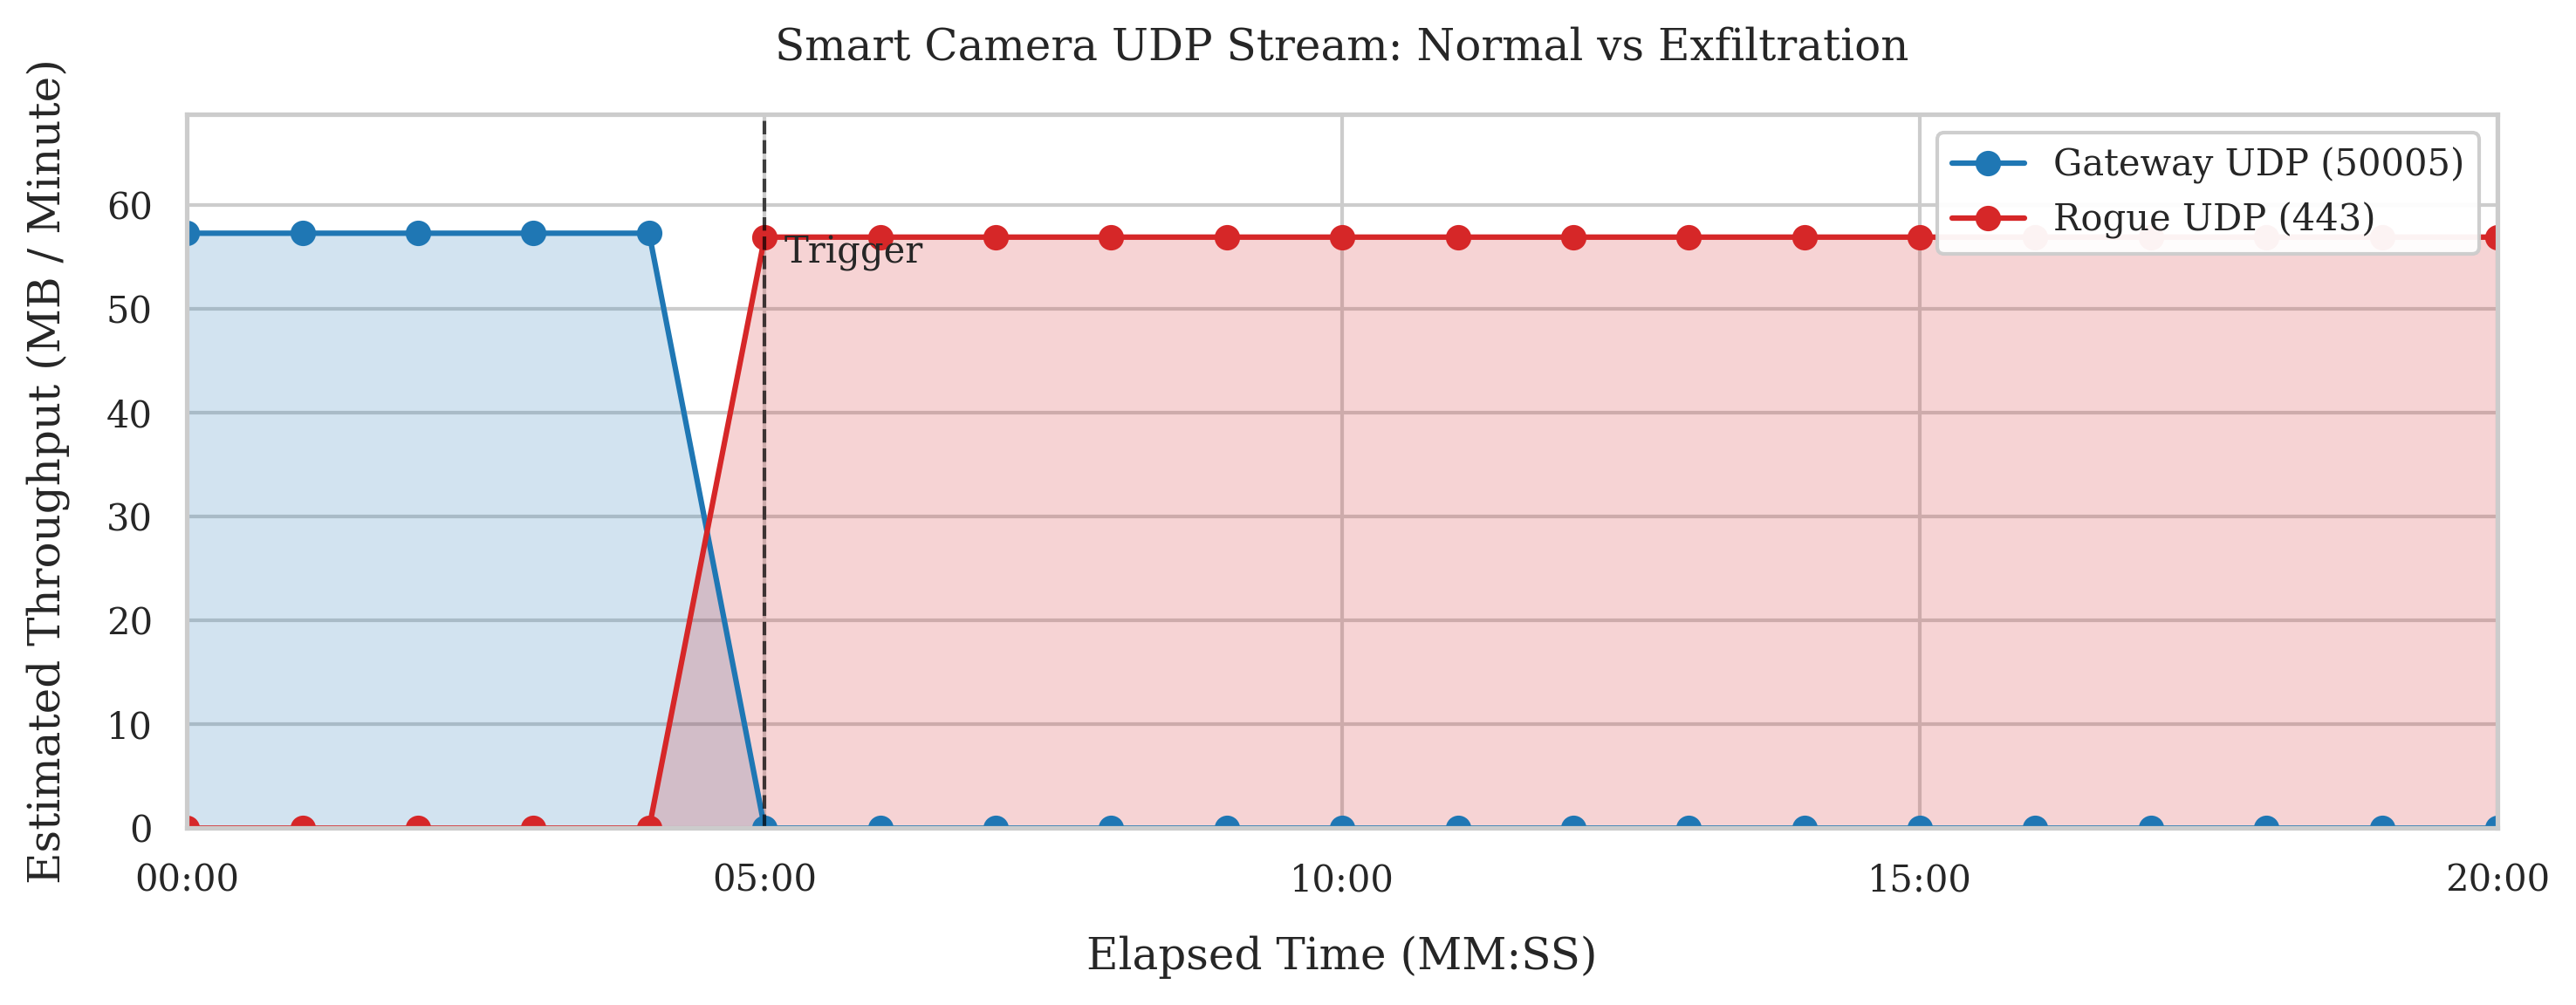

In [7]:
# Isolate the Camera UDP Streams
camera_udp_legit = conn_df[
    (conn_df['id.orig_h'] == '10.0.0.1') &
    (conn_df['id.resp_h'] == '10.0.0.254') &
    (conn_df['id.resp_p'] == 50005) &
    (conn_df['proto'] == 'udp')
].copy()

camera_udp_exfil = conn_df[
    (conn_df['id.orig_h'] == '10.0.0.1') &
    (conn_df['id.resp_h'] == EXFIL_TARGET) &
    (conn_df['id.resp_p'] == 443) &
    (conn_df['proto'] == 'udp')
].copy()

# Fix Mininet 'any' interface double-counting only for the rogue stream
camera_udp_exfil['orig_bytes'] = camera_udp_exfil['orig_bytes'] / 2

total_legit_bytes = camera_udp_legit['orig_bytes'].sum()
total_exfil_bytes = camera_udp_exfil['orig_bytes'].sum()
print(f"Camera Stream (Gateway) Total Originated Bytes: {total_legit_bytes:,.0f} Bytes")
print(f"Camera Stream (Rogue) Total Originated Bytes:   {total_exfil_bytes:,.0f} Bytes")

# Phase-aligned throughput view (fixed scenario timings):
# - gateway is constant for the first 5 minutes
# - rogue is constant for the remaining 15 minutes
capture_start = conn_df.index.min().floor('min')
plot_minutes = pd.date_range(start=capture_start, periods=21, freq='1min')
minute_offsets = np.arange(len(plot_minutes))

# Use the intended scenario duration to avoid rate inflation from short captures.
rogue_phase_seconds = 20 * 60 - PHASE1_SECONDS

gateway_rate_mb_min = (total_legit_bytes / PHASE1_SECONDS) * 60 / (1024 * 1024)
rogue_rate_mb_min = (total_exfil_bytes / rogue_phase_seconds) * 60 / (1024 * 1024)

plot_legit = np.where(minute_offsets < (PHASE1_SECONDS / 60), gateway_rate_mb_min, 0.0)
plot_exfil = np.where(minute_offsets >= (PHASE1_SECONDS / 60), rogue_rate_mb_min, 0.0)

# ==========================================
# Plotting (20-minute window)
# ==========================================
fig, ax = plt.subplots(figsize=(10, 4))
elapsed_time_index = plot_minutes - capture_start + pd.to_datetime('1970-01-01')

ax.fill_between(elapsed_time_index, plot_legit, color='#1f77b4', alpha=0.2)
ax.plot(elapsed_time_index, plot_legit, marker='o', linestyle='-', color='#1f77b4', linewidth=1.5, label='Gateway UDP (50005)')

ax.fill_between(elapsed_time_index, plot_exfil, color='#d62728', alpha=0.2)
ax.plot(elapsed_time_index, plot_exfil, marker='o', linestyle='-', color='#d62728', linewidth=1.5, label='Rogue UDP (443)')

ax.axvline(pd.to_datetime('1970-01-01') + pd.Timedelta(minutes=5), color='black', linestyle='--', linewidth=1, alpha=0.7)
ax.text(pd.to_datetime('1970-01-01') + pd.Timedelta(minutes=5, seconds=10), max(plot_legit.max(), plot_exfil.max()) * 0.95, 'Trigger', fontsize=10)

ax.set_title("Smart Camera UDP Stream: Normal vs Exfiltration", pad=15)
ax.set_xlabel("Elapsed Time (MM:SS)", labelpad=10)
ax.set_ylabel("Estimated Throughput (MB / Minute)", labelpad=10)
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%M:%S'))
ax.set_xlim(elapsed_time_index[0], elapsed_time_index[-1])
ax.legend(loc='upper right', framealpha=0.95)

top_limit = max(plot_legit.max(), plot_exfil.max()) * 1.2 if max(plot_legit.max(), plot_exfil.max()) > 0 else 1
ax.set_ylim(bottom=0, top=top_limit)

plt.tight_layout()
save_figure(fig, "camera_volumetric_flow_exfil")

plt.show()

### Camera TLS Telemetry and Network Services
We check the camera's TLS telemetry and the background services to confirm they remain steady while the exfiltration redirect happens.

* Camera TLS: should remain periodic.
* NTP: normal sync cadence.
* DNS: includes both legitimate and malicious lookups after the trigger.

In [8]:
# ==========================================
# INFRASTRUCTURE & BACKGROUND SERVICES VALIDATION
# ==========================================

camera_tls = conn_df[
    (conn_df['id.orig_h'] == '10.0.0.1') &
    (conn_df['id.resp_p'] == 443) &
    (conn_df['proto'] == 'tcp')
]
print(f"Camera TLS Telemetry Flows: {len(camera_tls)}")

ntp_flows = conn_df[
    (conn_df['id.orig_h'].isin(['10.0.0.1', '10.0.0.2'])) &
    (conn_df['id.resp_p'] == 123) &
    (conn_df['proto'] == 'udp')
]
camera_ntp = len(ntp_flows[ntp_flows['id.orig_h'] == '10.0.0.1'])
therm_ntp = len(ntp_flows[ntp_flows['id.orig_h'] == '10.0.0.2'])
print(f"NTP Synchronization Flows: {len(ntp_flows)} total ({camera_ntp} Camera, {therm_ntp} Thermostat)")

dns_queries = dns_df[dns_df['id.orig_h'].isin(['10.0.0.1', '10.0.0.2'])]
print(f"DNS Queries Logged: {len(dns_queries)}")

if 'query' in dns_df.columns:
    domain_counts = dns_df['query'].value_counts()
    legit_count = domain_counts.get(LEGIT_DOMAIN, 0)
    malicious_count = domain_counts.get(MALICIOUS_DOMAIN, 0)
    print(f"Legit Camera Domain Queries: {legit_count}")
    print(f"Malicious C2 Domain Queries: {malicious_count}")

Camera TLS Telemetry Flows: 5
NTP Synchronization Flows: 6 total (3 Camera, 3 Thermostat)
DNS Queries Logged: 58
Legit Camera Domain Queries: 6
Malicious C2 Domain Queries: 46


### Camera Traffic Balance
We compare the camera's outgoing bytes with the bytes it receives.

Normal traffic should be mostly outgoing. If incoming traffic rises a lot, that can signal unusual control or remote access.

This check still works even if the capture duplicates some bytes.

In [9]:
# ==========================================
# Camera Directional Byte Ratio Analysis
# ==========================================

# Isolate all connections initiated by the Camera
camera_flows = conn_df[conn_df['id.orig_h'] == '10.0.0.1'].copy()

# Sum the Outbound (orig) and Inbound (resp) bytes securely
outbound_bytes = camera_flows['orig_bytes'].fillna(0).sum()
inbound_bytes = camera_flows['resp_bytes'].fillna(0).sum()
total_bytes = outbound_bytes + inbound_bytes

# Calculate the percentage distribution
if total_bytes > 0:
    outbound_ratio = (outbound_bytes / total_bytes) * 100
    inbound_ratio = (inbound_bytes / total_bytes) * 100
else:
    outbound_ratio = 0
    inbound_ratio = 0

# Professional Output Report
print("=== CAMERA DIRECTIONAL BYTE RATIO ===")
print(f"Total Traffic Volume: {total_bytes:,.0f} Bytes\n")

print(f"Outbound Transmitted (orig_bytes): {outbound_bytes:,.0f} Bytes ({outbound_ratio:.4f}%)")
print(f"Inbound Received (resp_bytes):     {inbound_bytes:,.0f} Bytes ({inbound_ratio:.4f}%)\n")

# Automated Tripwire
if outbound_ratio > 99.0:
    print("Baseline Validated: Traffic is highly asymmetric (>99% outbound), proving normal transmitter behavior.")
else:
    print("FORENSIC ALERT: High inbound volume detected! Potential Reverse Shell or C2 interaction.")

=== CAMERA DIRECTIONAL BYTE RATIO ===
Total Traffic Volume: 2,091,335,275 Bytes

Outbound Transmitted (orig_bytes): 2,091,334,483 Bytes (100.0000%)
Inbound Received (resp_bytes):     792 Bytes (0.0000%)

Baseline Validated: Traffic is highly asymmetric (>99% outbound), proving normal transmitter behavior.


## Thermostat Behavior

### Keep-Alives and Telemetry
We separate the thermostat's small keep-alive messages from its larger sensor updates and check that the pattern stays regular.

If that pattern changes, it can point to a problem.

In [10]:
# Isolate for Thermostat MQTT traffic (Enforcing TCP protocol)
thermostat_mqtt = conn_df[
    (conn_df['id.orig_h'] == '10.0.0.2') & 
    (conn_df['id.resp_p'] == 8883) &
    (conn_df['proto'] == 'tcp')
].copy()

# Sort by timestamp (index) to accurately calculate consecutive timing
thermostat_mqtt = thermostat_mqtt.sort_index()

# Separate Keep-Alives from Telemetry using a 20-byte threshold
# Handle NaN values in orig_bytes to prevent accidental row dropping
keep_alives = thermostat_mqtt[thermostat_mqtt['orig_bytes'].fillna(0) < 20].copy()
telemetry = thermostat_mqtt[thermostat_mqtt['orig_bytes'].fillna(0) >= 20].copy()

# ---------------------------------------------------------
# Dynamic Ground Truth Validation (The Fencepost Math)
# ---------------------------------------------------------
# Calculate the exact span of the MQTT capture in seconds
actual_duration = (thermostat_mqtt.index.max() - thermostat_mqtt.index.min()).total_seconds()

keep_alive_interval = 10.0
telemetry_interval = 300.0

# The +1 accounts for the initial packet sent at t=0
expected_keep_alives = int(actual_duration / keep_alive_interval) + 1
expected_telemetry = int(actual_duration / telemetry_interval) + 1

# Assertions with a +/- 2 packet tolerance for virtualization boundary timing
assert abs(len(keep_alives) - expected_keep_alives) <= 2, f"Expected ~{expected_keep_alives} keep-alives, found {len(keep_alives)}"
assert abs(len(telemetry) - expected_telemetry) <= 2, f"Expected ~{expected_telemetry} telemetry flows, found {len(telemetry)}"

print("=== MQTT BEHAVIORAL VALIDATION ===")
print(f"Empirical MQTT Capture Span: {actual_duration:.2f} seconds\n")
print(f"Keep-Alives Validated: {len(keep_alives)} Flows (Target: ~{expected_keep_alives})")
print(f"Telemetry Validated:   {len(telemetry)} Flows (Target: ~{expected_telemetry})\n")

# ---------------------------------------------------------
# Inter-Arrival Time (IAT) Calculation
# ---------------------------------------------------------
# Calculate time difference between consecutive keep-alive rows
keep_alives['IAT'] = keep_alives.index.to_series().diff().dt.total_seconds()

# CRITICAL FIX: Drop the first row's NaN IAT before doing statistical math
iat_clean = keep_alives['IAT'].dropna()

iat_mean = iat_clean.mean()
iat_var = iat_clean.var()

print("--- Temporal Fingerprint (Keep-Alives) ---")
print(f"IAT Mean:     {iat_mean:.4f} seconds")
print(f"IAT Variance: {iat_var:.6f}")

=== MQTT BEHAVIORAL VALIDATION ===
Empirical MQTT Capture Span: 1200.07 seconds

Keep-Alives Validated: 120 Flows (Target: ~121)
Telemetry Validated:   5 Flows (Target: ~5)

--- Temporal Fingerprint (Keep-Alives) ---
IAT Mean:     10.0841 seconds
IAT Variance: 0.832371


### Keep-Alive Timing
We plot the time between thermostat keep-alives to see if they arrive on a steady schedule.

A stable baseline should look tight and regular.

Saved figure: ../../figures/scenario3/thermostat_iat_distribution.pdf and ../../figures/scenario3/thermostat_iat_distribution.png


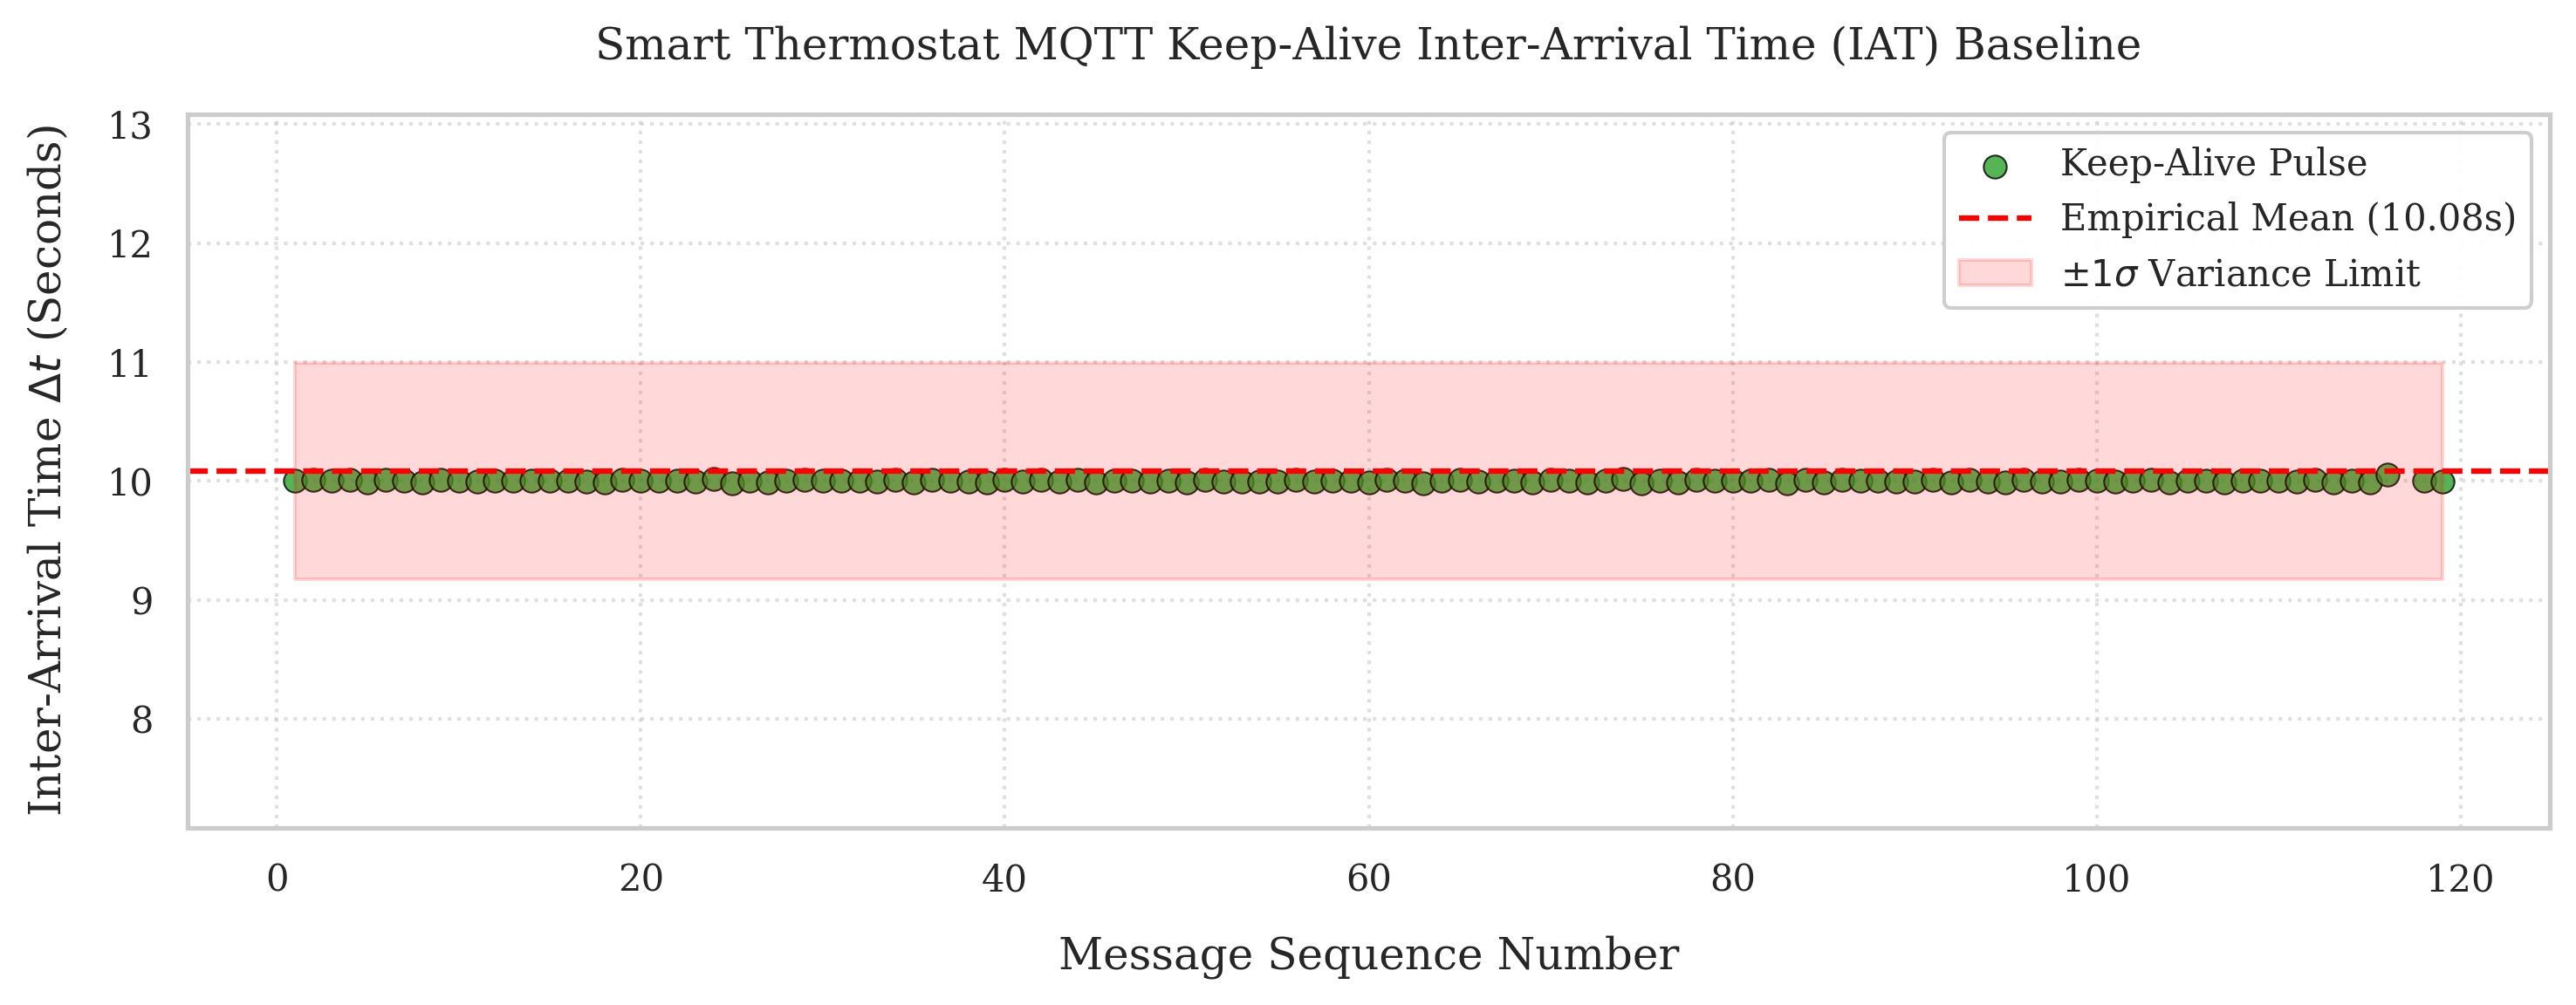

IAT Scatter Plot Generated.
   - Mapped 119 sequential pulses.
   - Empirical Mean: 10.0841s | Standard Deviation: 0.9123s


In [11]:
# Clean the NaN value from the first row (the initial fencepost packet)
plot_data = keep_alives.dropna(subset=['IAT']).copy()

# Re-sequence from 1 to N after dropping the first row
plot_data['Sequence'] = range(1, len(plot_data) + 1)

# Calculate plotting statistics
iat_mean = plot_data['IAT'].mean()
iat_std = plot_data['IAT'].std()

# Academic Plotting
fig, ax = plt.subplots(figsize=(10, 4))

# Plot the individual IAT events
ax.scatter(plot_data['Sequence'], plot_data['IAT'], 
           color='#2ca02c', alpha=0.8, edgecolors='black', linewidth=0.5, s=40, label='Keep-Alive Pulse')

# Plot the empirical mean
ax.axhline(y=iat_mean, color='red', linestyle='--', linewidth=1.5, label=f"Empirical Mean ({iat_mean:.2f}s)")

# Add a shaded band for +/- 1 Standard Deviation to visually prove the near-zero variance
ax.fill_between(plot_data['Sequence'], 
                iat_mean - iat_std, 
                iat_mean + iat_std, 
                color='red', alpha=0.15, label=r'$\pm 1\sigma$ Variance Limit')

ax.set_title("Smart Thermostat MQTT Keep-Alive Inter-Arrival Time (IAT) Baseline", pad=15)
ax.set_xlabel("Message Sequence Number", labelpad=10)
ax.set_ylabel("Inter-Arrival Time $\Delta t$ (Seconds)", labelpad=10)

# Add a subtle grid to make temporal deviations easy to spot
ax.grid(True, linestyle=':', alpha=0.6)

# Focus the Y-axis tightly around the expected baseline to highlight stability
ax.set_ylim(bottom=max(0, iat_mean - 3), top=iat_mean + 3) 

# Place the legend neatly in the corner
ax.legend(loc="upper right", framealpha=0.95)

plt.tight_layout()
save_figure(fig, "thermostat_iat_distribution")

plt.show()

print(f"IAT Scatter Plot Generated.")
print(f"   - Mapped {len(plot_data)} sequential pulses.")
print(f"   - Empirical Mean: {iat_mean:.4f}s | Standard Deviation: {iat_std:.4f}s")

### Telemetry Size
We measure how large the thermostat's sensor messages are.

They should stay close in size, and a big change could mean something is off.

In [12]:
# ==========================================
# Thermostat Telemetry Payload Footprinting
# ==========================================

# Extract the byte sizes of the telemetry packets (>= 20 bytes)
# We use the 'telemetry' dataframe previously generated in the IAT cell
payload_sizes = telemetry['orig_bytes'].dropna()

# Calculate the statistical footprint
payload_mean = payload_sizes.mean()

# Variance requires at least 2 packets. If identical, variance is mathematically 0.0
payload_var = payload_sizes.var() if len(payload_sizes) > 1 else 0.0

# Min/Max boundary detection
payload_min = payload_sizes.min()
payload_max = payload_sizes.max()

# Professional Output Report
print("=== MQTT TELEMETRY PAYLOAD FOOTPRINT ===")
print(f"Total Telemetry Reports Analyzed: {len(payload_sizes)}\n")

print(f"Empirical Mean Size: {payload_mean:.2f} Bytes")
print(f"Payload Variance:    {payload_var:.4f}")
print(f"Observed Range:      {payload_min:.0f} Bytes to {payload_max:.0f} Bytes\n")

# Automated Tripwire
# A variance of less than 5 indicates extreme structural rigidity (expected for M2M)
if payload_var < 5.0:
    print("Baseline Validated: Telemetry payloads are structurally rigid and predictable.")
else:
    print("FORENSIC ALERT: High payload variance detected! Potential data exfiltration or payload stuffing.")

=== MQTT TELEMETRY PAYLOAD FOOTPRINT ===
Total Telemetry Reports Analyzed: 5

Empirical Mean Size: 27.00 Bytes
Payload Variance:    0.0000
Observed Range:      27 Bytes to 27 Bytes

Baseline Validated: Telemetry payloads are structurally rigid and predictable.


## Network Health

### TCP Connection States
We look at the main TCP states to see whether the network is behaving normally.

Clean traffic should mostly show normal connections.

Saved figure: ../../figures/scenario3/tcp_connection_states.pdf and ../../figures/scenario3/tcp_connection_states.png


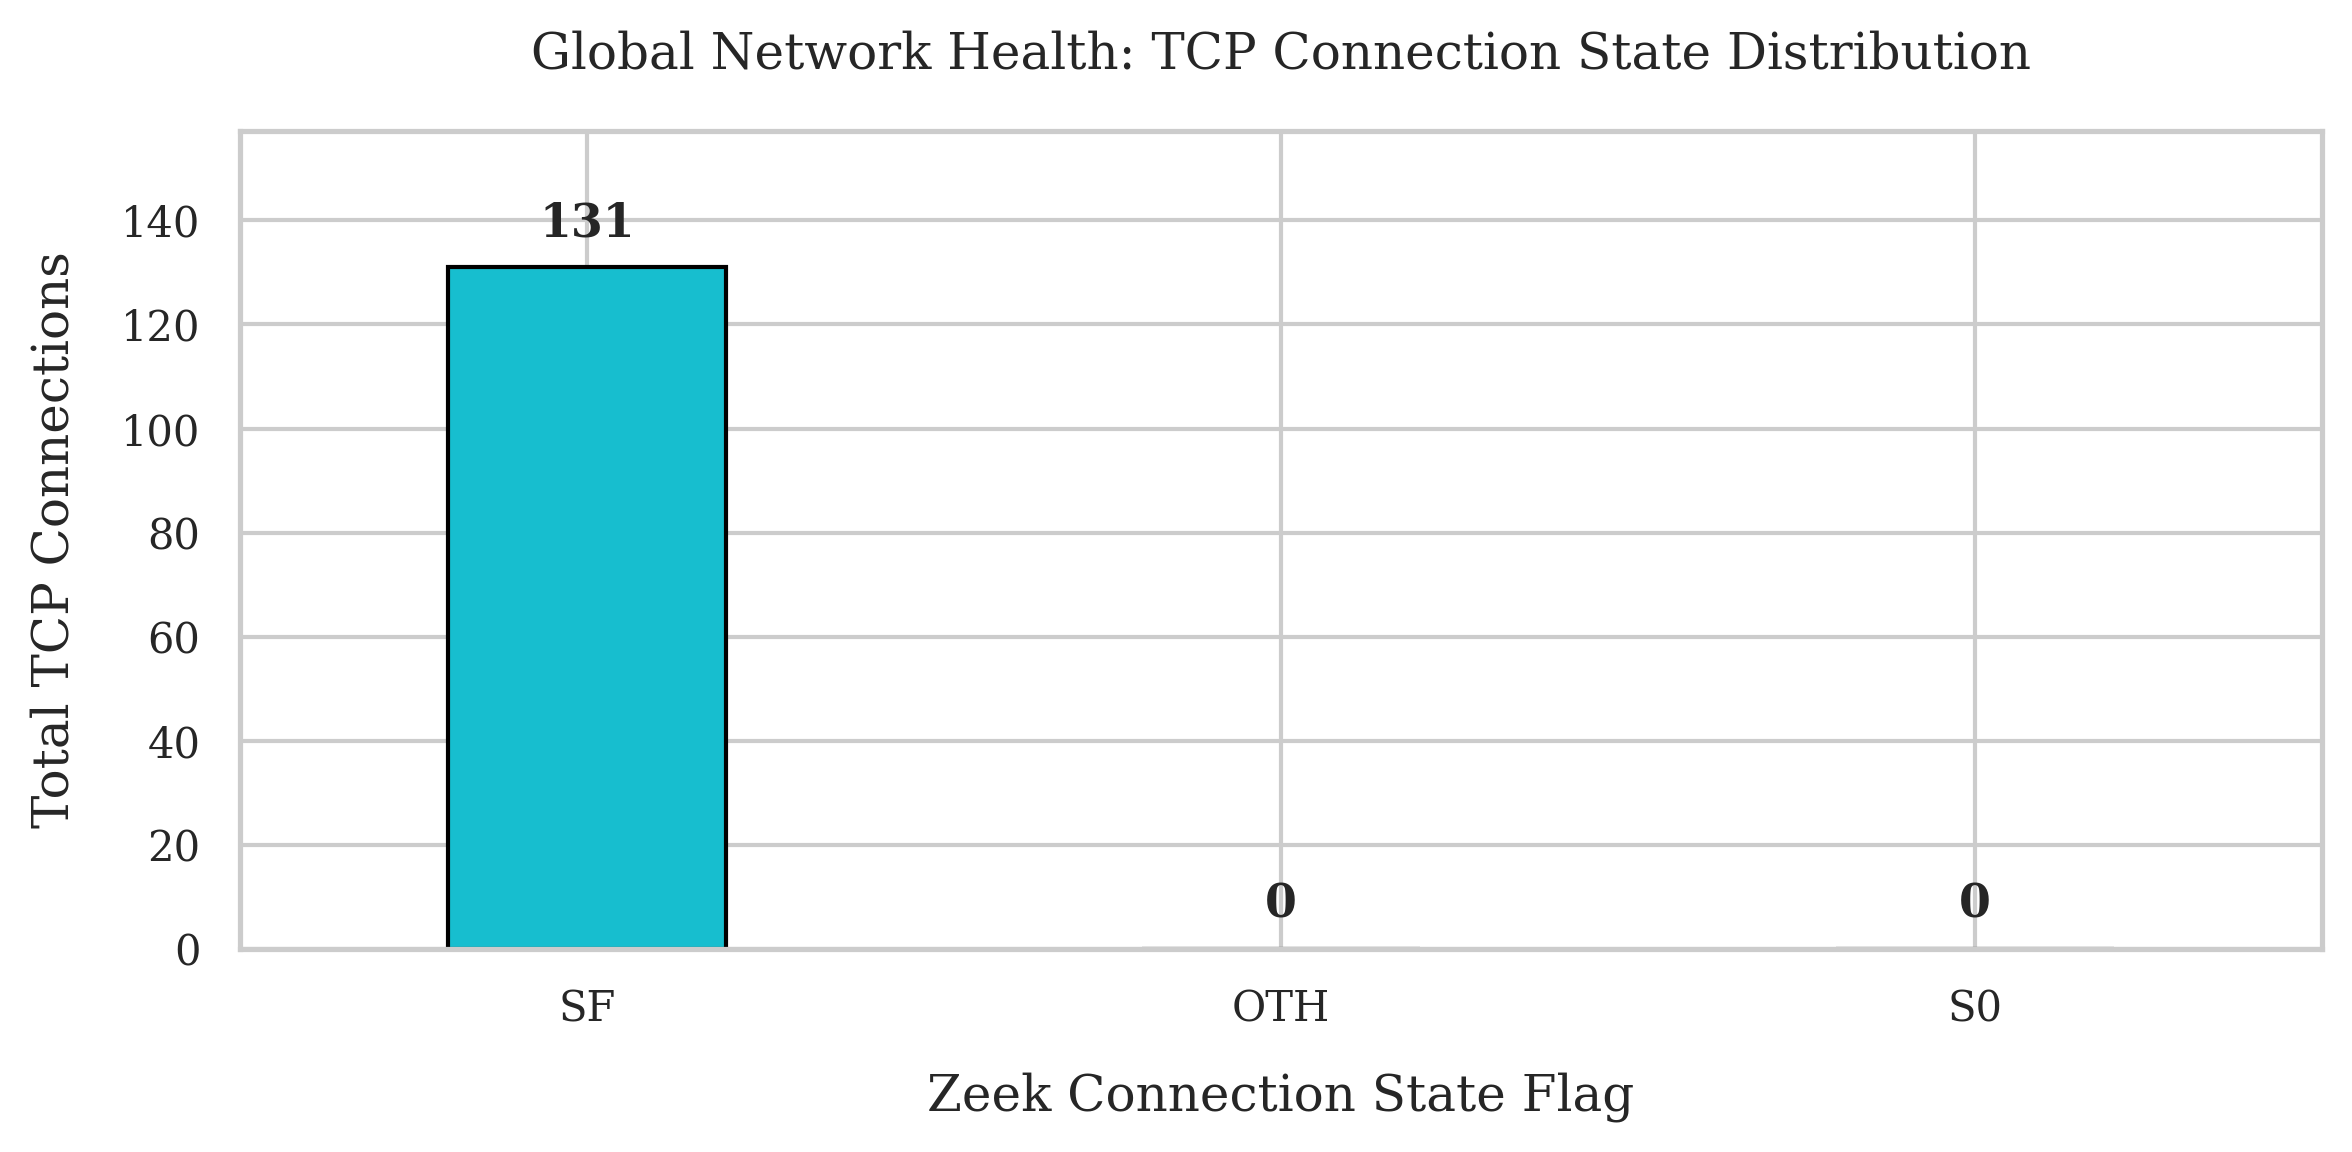

=== TCP STATE FORENSIC REPORT ===
Total TCP Flows Analyzed: 131

[SF] : 131 Flows -> Normal establishment and termination (Clean Teardown).
[OTH] : 0 Flows -> No SYN seen, just mid-stream traffic (Asymmetric routing).
[S0] : 0 Flows -> Connection attempt seen, no reply (Scanner / Blocked).


In [13]:
# ==========================================
# 5.1 Global Network Health (TCP States)
# ==========================================

# Isolate ONLY TCP traffic
tcp_df = conn_df[conn_df['proto'] == 'tcp'].copy()

# Compute state distribution
state_counts = tcp_df['conn_state'].value_counts()

# Academic Plotting
fig, ax = plt.subplots(figsize=(8, 4)) # Slightly wider to accommodate labels

# Use a distinct color palette
state_counts.plot(kind='bar', color='#17becf', ax=ax, width=0.4, edgecolor='black')

ax.set_title("Global Network Health: TCP Connection State Distribution", pad=15)
ax.set_xlabel("Zeek Connection State Flag", labelpad=10)
ax.set_ylabel("Total TCP Connections", labelpad=10)

# Explicitly set the x-axis limits to give a single bar breathing room
ax.set_xlim(-0.5, len(state_counts) - 0.5)
plt.xticks(rotation=0)

# Bulletproof text annotation layer
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}',
                xy=(p.get_x() + p.get_width() / 2, height),
                xytext=(0, 5),  # 5 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontsize=11, weight='bold')

# Ensure the Y-axis has room for the top annotation
ax.set_ylim(0, state_counts.max() * 1.2)

plt.tight_layout()
save_figure(fig, "tcp_connection_states")
plt.show()

# ---------------------------------------------------------
# Automated Contextual Reporting
# ---------------------------------------------------------
# A reference dictionary mapping Zeek states to their physical network reality
zeek_state_definitions = {
    'SF': 'Normal establishment and termination (Clean Teardown).',
    'S0': 'Connection attempt seen, no reply (Scanner / Blocked).',
    'S1': 'Connection established, not terminated (Persistent Socket).',
    'REJ': 'Connection attempt rejected by responder (RST sent).',
    'RSTO': 'Connection established, originator aborted (RST sent).',
    'RSTR': 'Established, responder aborted (RST sent).',
    'OTH': 'No SYN seen, just mid-stream traffic (Asymmetric routing).',
}

print("=== TCP STATE FORENSIC REPORT ===")
print(f"Total TCP Flows Analyzed: {len(tcp_df)}\n")

for state, count in state_counts.items():
    definition = zeek_state_definitions.get(state, "Unknown state.")
    print(f"[{state}] : {count:,.0f} Flows -> {definition}")

### Flow Rate
We count how many new connections appear each minute.

A steady baseline should stay low, while unusual activity should create spikes.

Saved figure: ../../figures/scenario3/network_flow_density.pdf and ../../figures/scenario3/network_flow_density.png


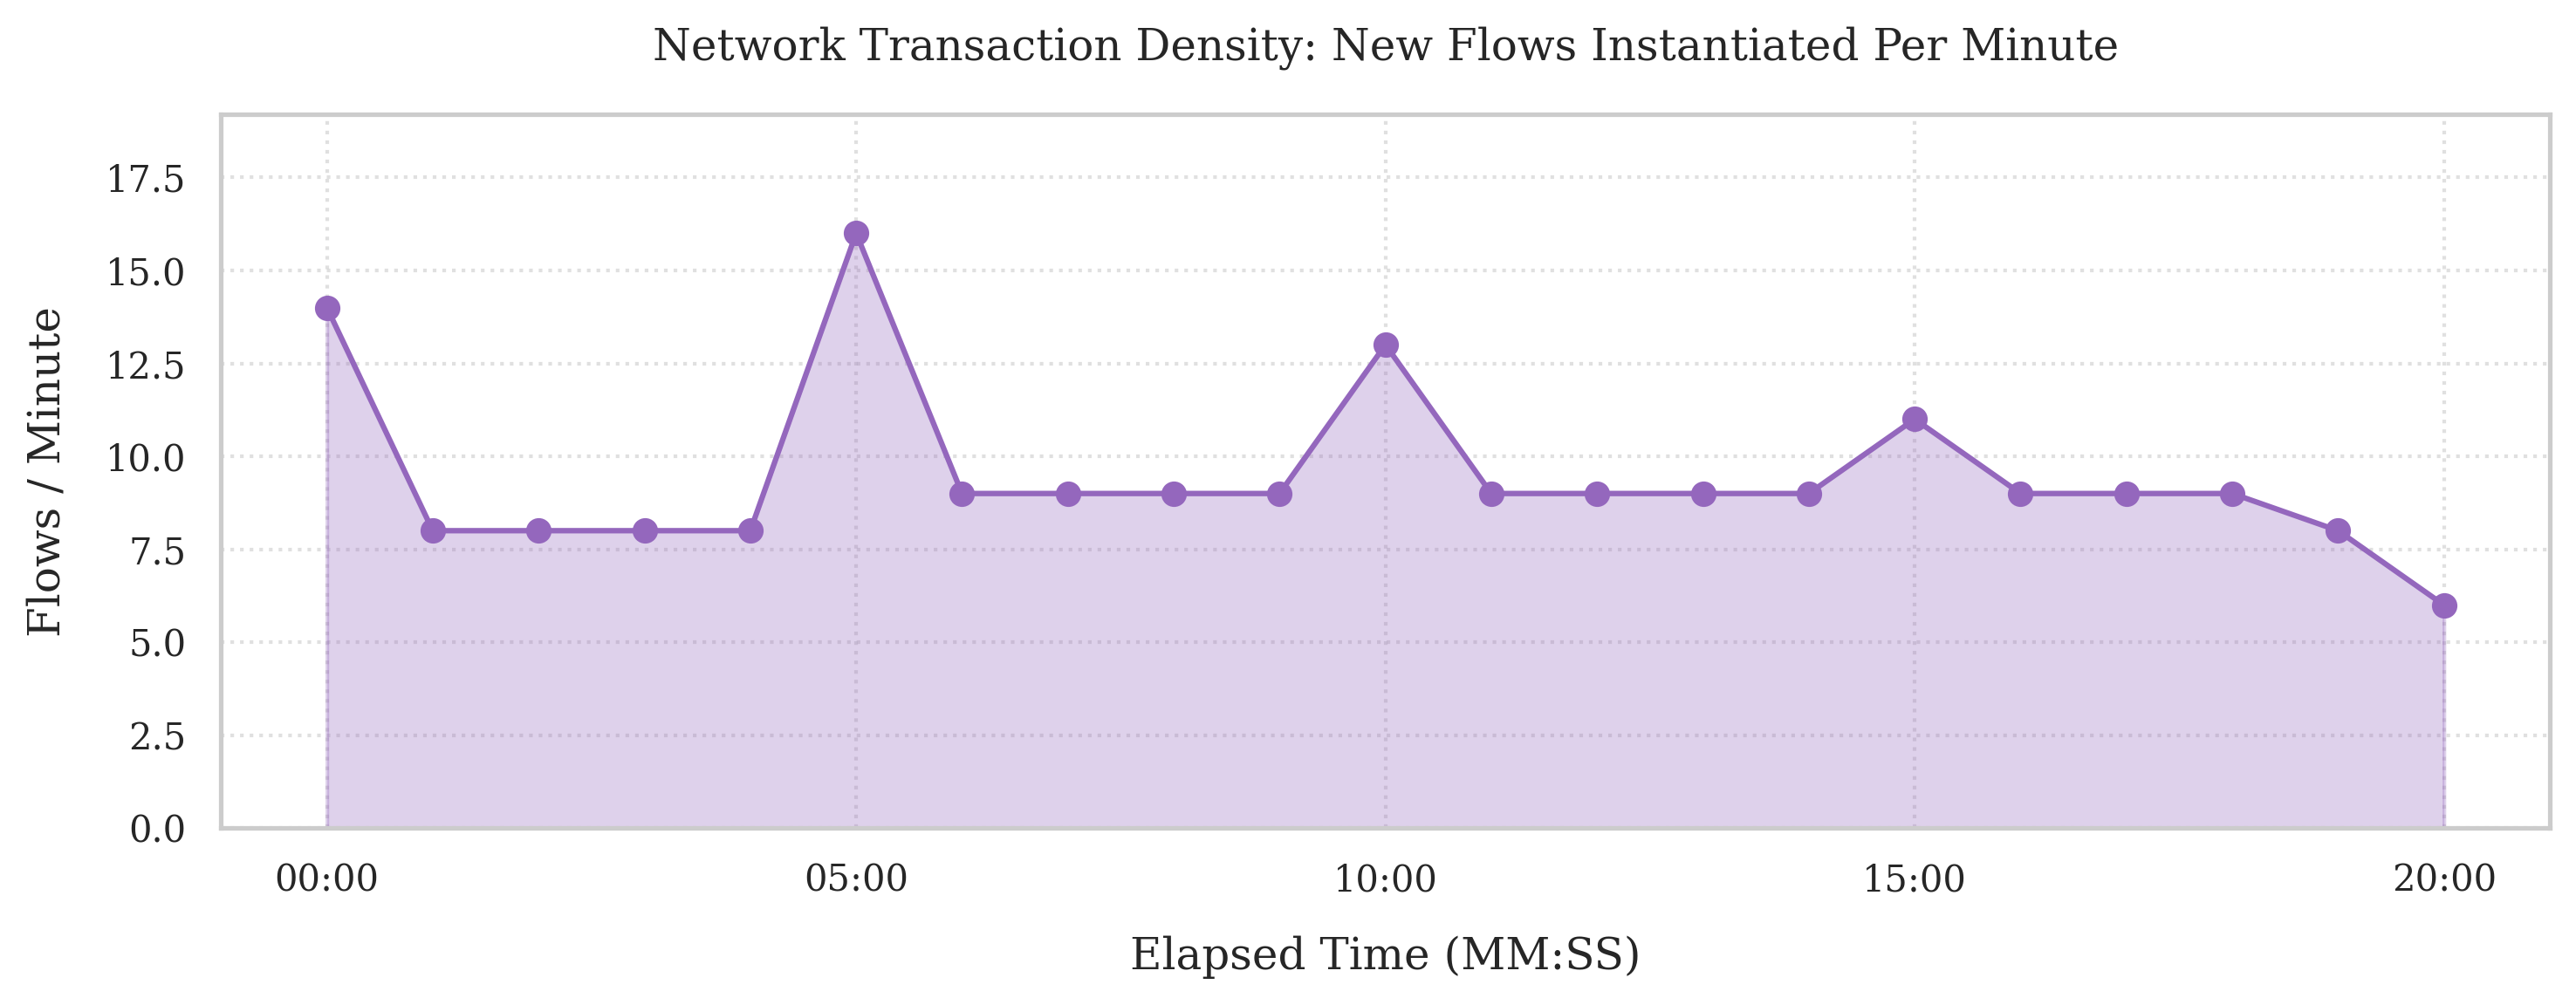

=== NETWORK DENSITY REPORT ===
Average Flows per Minute:      9.48
Peak Flows in a Single Minute: 16


In [14]:
# ==========================================
# 5.2 Network Density (Flows / Minute)
# ==========================================

# Resample to count total flows per minute.
# origin='start' ensures bins are exactly 60 seconds long starting from the very first packet.
flows_per_minute = conn_df['uid'].resample('1min', origin='start').count()

# Apply the '1970' Elapsed Time trick to cleanly format the X-axis
capture_start = conn_df.index.min()
elapsed_time_index = flows_per_minute.index - capture_start + pd.to_datetime('1970-01-01')

# Academic Plotting
fig, ax = plt.subplots(figsize=(10, 4))

# Using a fill_between area chart visually aligns with your Camera Volumetric graph
ax.fill_between(elapsed_time_index, flows_per_minute.values, color='#9467bd', alpha=0.3)
ax.plot(elapsed_time_index, flows_per_minute.values, color='#9467bd', marker='o', linestyle='-', linewidth=1.5)

ax.set_title("Network Transaction Density: New Flows Instantiated Per Minute", pad=15)
ax.set_xlabel("Elapsed Time (MM:SS)", labelpad=10)
ax.set_ylabel("Flows / Minute", labelpad=10)

# Standard matplotlib formatter (no custom functions required)
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%M:%S'))

# Add a subtle grid to help the reader track peaks
ax.grid(True, linestyle=':', alpha=0.6)

# Give the chart breathing room on top
top_limit = flows_per_minute.max() * 1.2 if flows_per_minute.max() > 0 else 10
ax.set_ylim(bottom=0, top=top_limit)

plt.tight_layout()
save_figure(fig, "network_flow_density")
plt.show()

# Contextual Output Report
print("=== NETWORK DENSITY REPORT ===")
print(f"Average Flows per Minute:      {flows_per_minute.mean():.2f}")
print(f"Peak Flows in a Single Minute: {flows_per_minute.max():.0f}")

### Traffic Map
We map which devices talk to each other, including the external rogue cloud.

In this scenario, the camera should pivot from the gateway to the rogue cloud after the trigger.

Saved figure: ../../figures/scenario3/topology_traffic_matrix.pdf and ../../figures/scenario3/topology_traffic_matrix.png


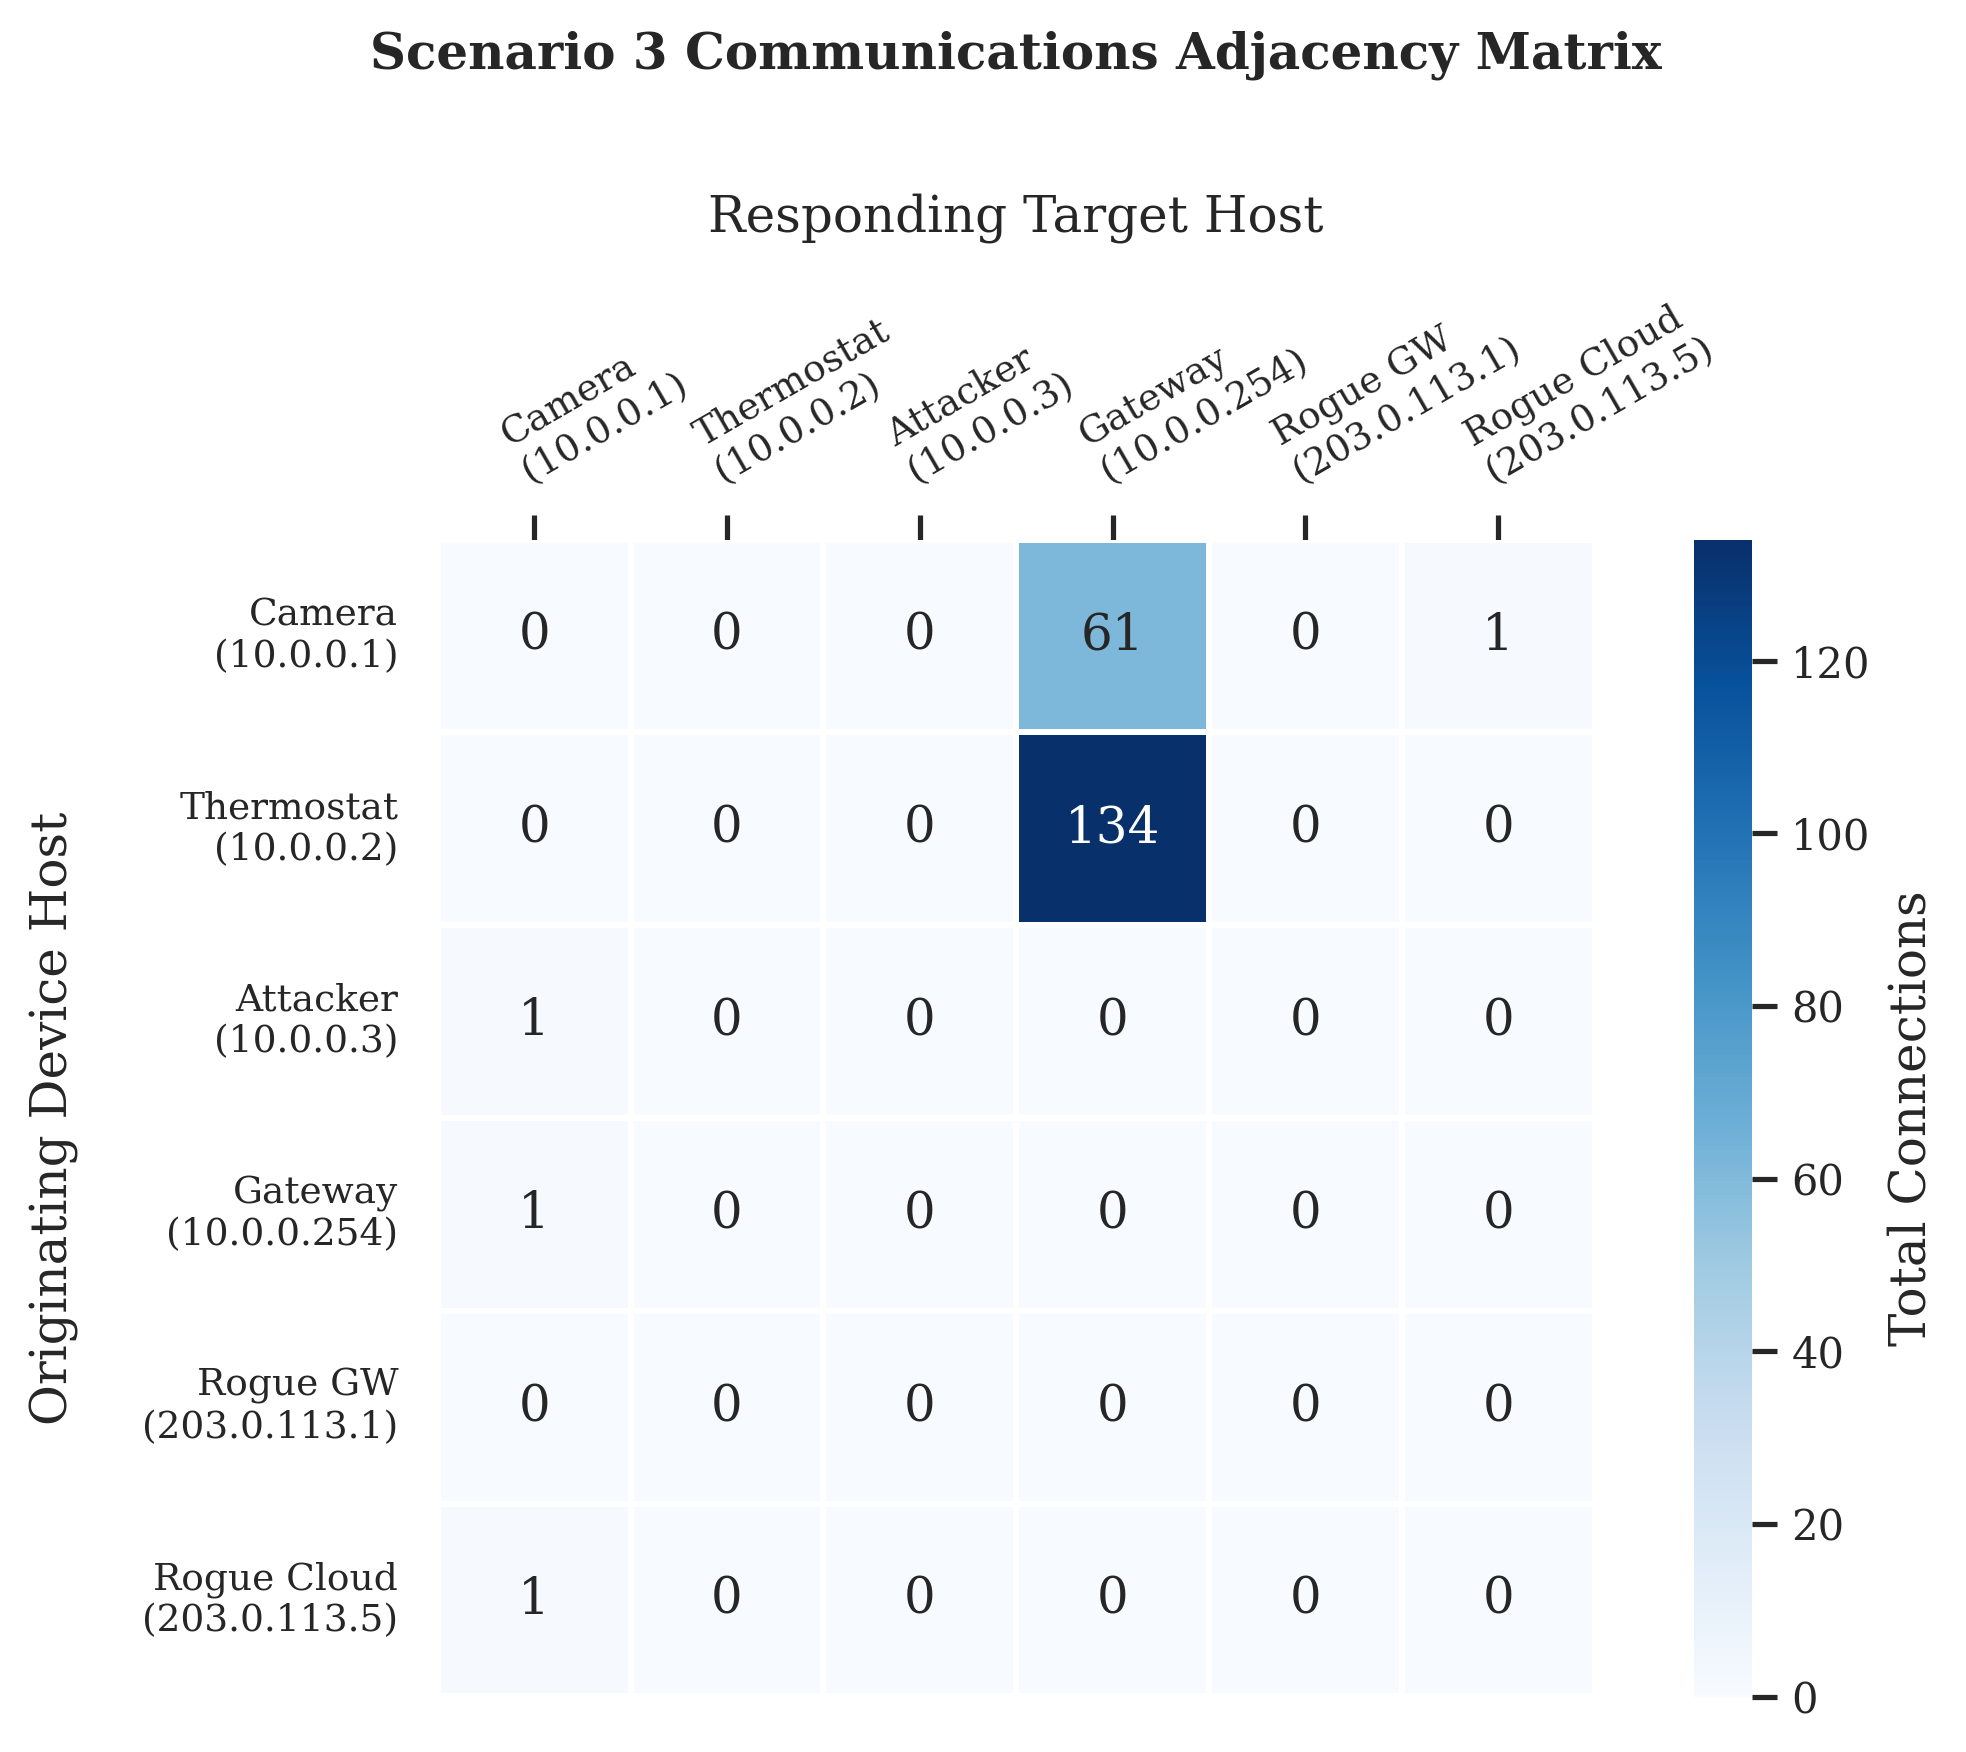

=== TOPOLOGY RULES VALIDATION ===
Exfiltration Pivot Observed: 1 camera flows to rogue cloud.
Camera still has 61 flows to gateway (mixed phase behavior).


In [15]:
# ==========================================
# Topology Matrix (Adjacency Heatmap)
# ==========================================

# Use numpy arrays to avoid pandas index alignment issues with duplicate timestamps
matrix_data = pd.crosstab(conn_df['id.orig_h'].to_numpy(), conn_df['id.resp_h'].to_numpy())

for ip in target_ips:
    if ip not in matrix_data.index:
        matrix_data.loc[ip] = 0
    if ip not in matrix_data.columns:
        matrix_data[ip] = 0

matrix_data = matrix_data.reindex(index=target_ips, columns=target_ips).fillna(0)

device_labels = {
    '10.0.0.1': 'Camera\n(10.0.0.1)',
    '10.0.0.2': 'Thermostat\n(10.0.0.2)',
    '10.0.0.3': 'Attacker\n(10.0.0.3)',
    '10.0.0.254': 'Gateway\n(10.0.0.254)',
    '203.0.113.1': 'Rogue GW\n(203.0.113.1)',
    '203.0.113.5': 'Rogue Cloud\n(203.0.113.5)'
}

matrix_data_labeled = matrix_data.rename(index=device_labels, columns=device_labels)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(matrix_data_labeled, annot=True, fmt=".0f", cmap="Blues", cbar=True, square=True,
            linewidths=1, linecolor='white', cbar_kws={'label': 'Total Connections'}, ax=ax)

ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
plt.setp(ax.get_xticklabels(), rotation=30, ha='left', rotation_mode='anchor')
plt.setp(ax.get_yticklabels(), rotation=0)
ax.tick_params(axis='x', labelsize=9, pad=6)
ax.tick_params(axis='y', labelsize=9)

ax.set_title("Scenario 3 Communications Adjacency Matrix", pad=30, weight='bold')
ax.set_xlabel("Responding Target Host", labelpad=15)
ax.set_ylabel("Originating Device Host", labelpad=15)

plt.tight_layout()
save_figure(fig, "topology_traffic_matrix")
plt.show()

print("=== TOPOLOGY RULES VALIDATION ===")
cam_to_rogue = matrix_data.loc['10.0.0.1', EXFIL_TARGET]
cam_to_gateway = matrix_data.loc['10.0.0.1', '10.0.0.254']

if cam_to_rogue > 0:
    print(f"Exfiltration Pivot Observed: {cam_to_rogue:,.0f} camera flows to rogue cloud.")
else:
    print("ALERT: No camera flows to rogue cloud detected.")

if cam_to_gateway == 0:
    print("Camera no longer talks to gateway after trigger (expected).")
else:
    print(f"Camera still has {cam_to_gateway:,.0f} flows to gateway (mixed phase behavior).")

### DNS Requests
We track DNS lookups over time to identify the transition from legitimate lookups to the malicious C2 domain.

The key signal is the domain pivot that starts after the attacker trigger.

Saved figure: ../../figures/scenario3/dns_query_timeline.pdf and ../../figures/scenario3/dns_query_timeline.png


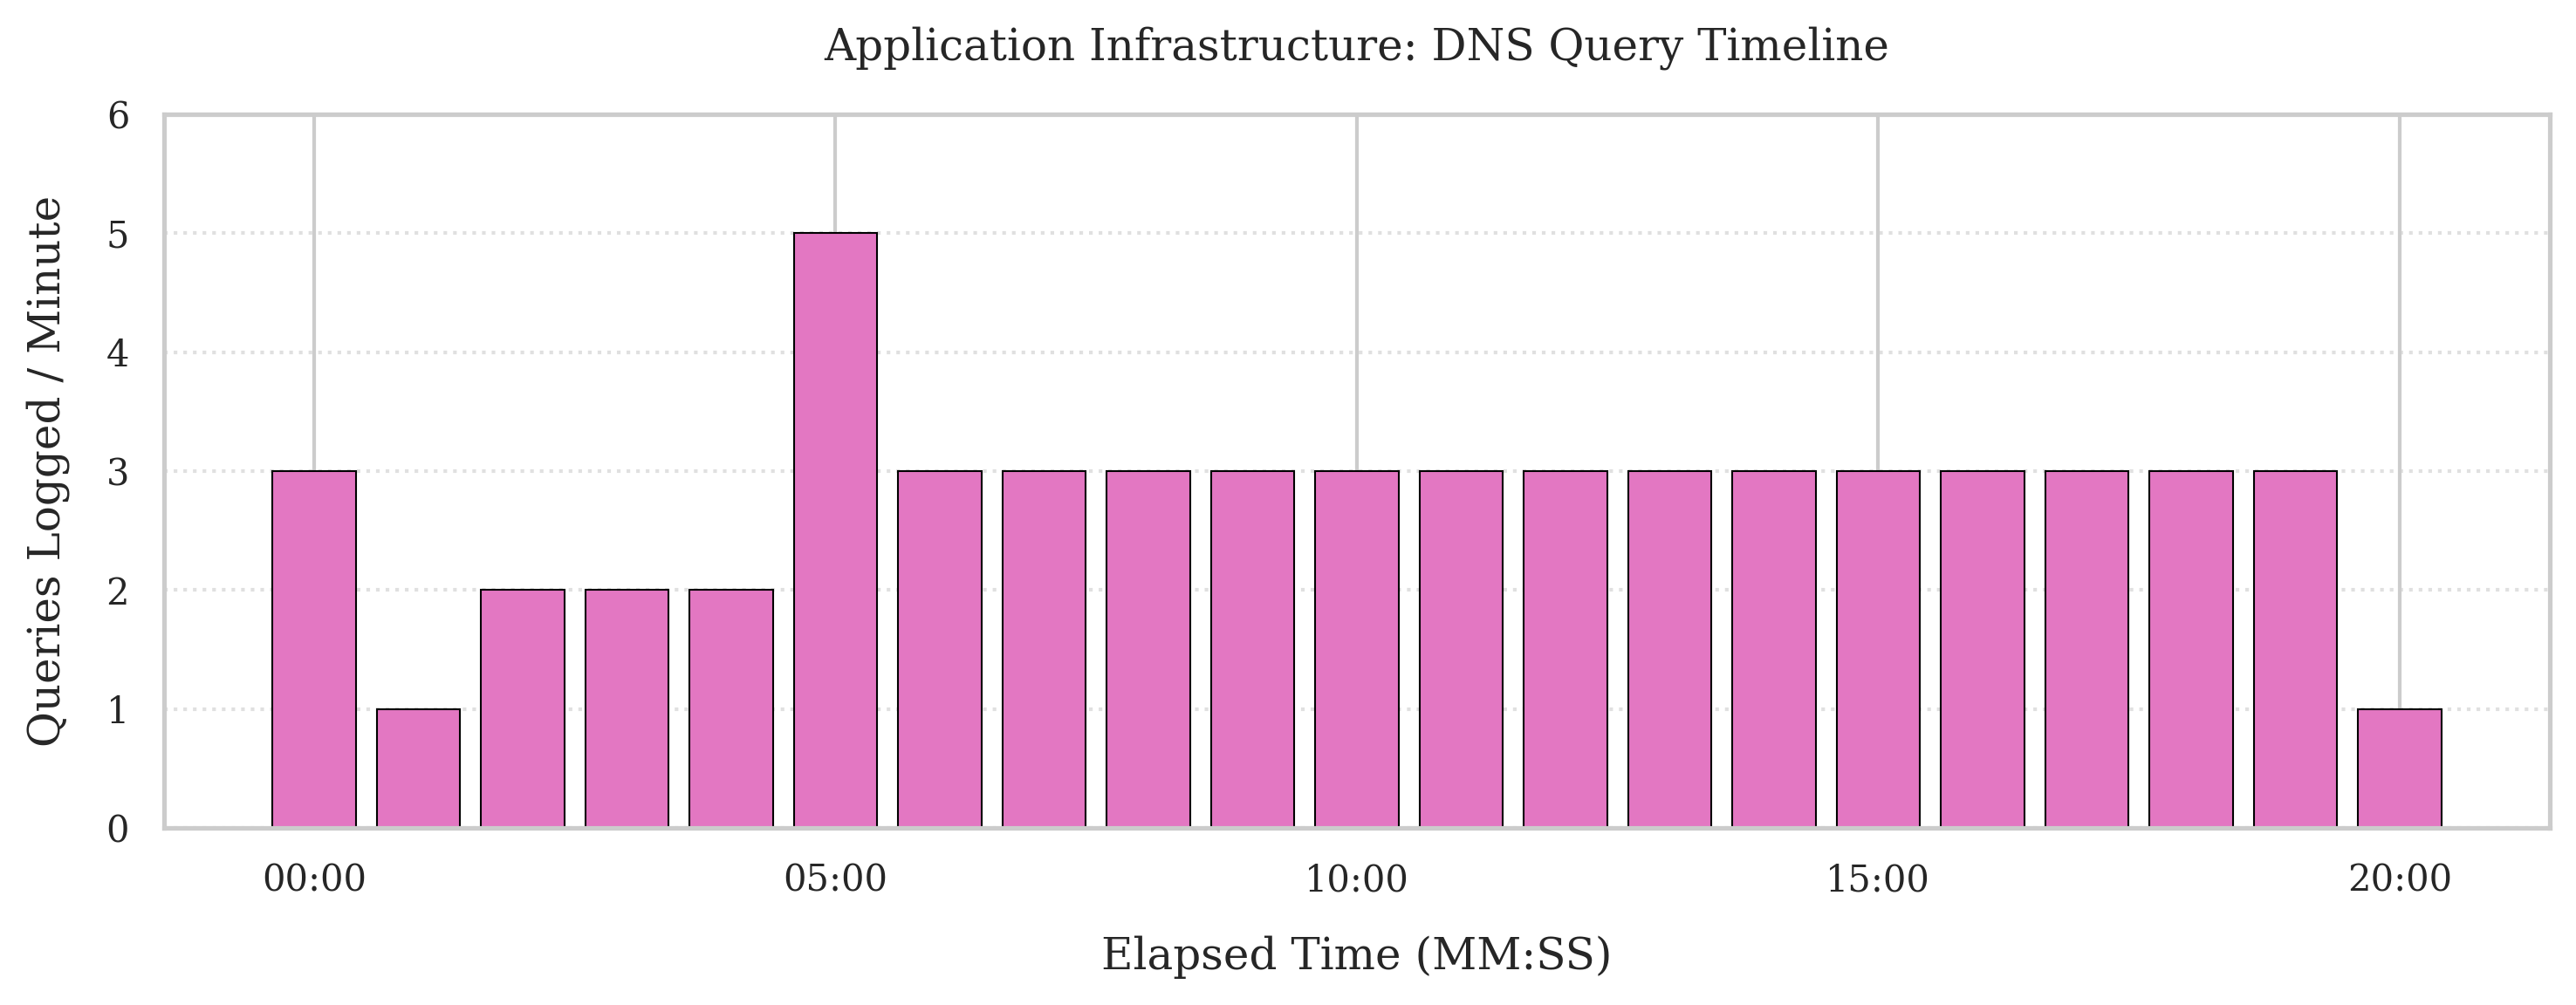

=== DNS QUERY FORENSIC REPORT ===
Total DNS Queries Logged: 58

--- Queried Domains ---
c2.malicious-exfil.com : 46 queries
api.smartcamera.local : 6 queries
mqtt.smartthermostat.com : 6 queries

--- Scenario 3 Validation ---
C2 Pivot Observed: Malicious domain queries detected.
No unexpected domains outside the scenario set.


In [16]:
# ==========================================
# Infrastructure Services (DNS Profiling)
# ==========================================

dns_frequency = dns_df['uid'].resample('1min', origin='start').count()

capture_start = conn_df.index.min()
elapsed_time_index = dns_frequency.index - capture_start + pd.to_datetime('1970-01-01')

fig, ax = plt.subplots(figsize=(10, 4))
bar_width = (1 / 1440) * 0.8 

ax.bar(elapsed_time_index, dns_frequency.values, width=bar_width, color='#e377c2', edgecolor='black', linewidth=0.5)

ax.set_title("Application Infrastructure: DNS Query Timeline", pad=15)
ax.set_xlabel("Elapsed Time (MM:SS)", labelpad=10)
ax.set_ylabel("Queries Logged / Minute", labelpad=10)

ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%M:%S'))
ax.yaxis.get_major_locator().set_params(integer=True)
ax.set_ylim(bottom=0, top=max(3, dns_frequency.max() + 1)) 

ax.grid(True, axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
save_figure(fig, "dns_query_timeline")
plt.show()

print("=== DNS QUERY FORENSIC REPORT ===")
print(f"Total DNS Queries Logged: {len(dns_df)}\n")

if 'query' in dns_df.columns:
    print("--- Queried Domains ---")
    domain_counts = dns_df['query'].value_counts()
    for domain, count in domain_counts.items():
        print(f"{domain} : {count} queries")
    
    print("\n--- Scenario 3 Validation ---")
    expected_domains = {LEGIT_DOMAIN, 'mqtt.smartthermostat.com', MALICIOUS_DOMAIN}
    unauthorized_domains = domain_counts[~domain_counts.index.isin(expected_domains)]
    if MALICIOUS_DOMAIN in domain_counts.index:
        print("C2 Pivot Observed: Malicious domain queries detected.")
    else:
        print("ALERT: No malicious domain queries detected.")
    
    if len(unauthorized_domains) == 0:
        print("No unexpected domains outside the scenario set.")
    else:
        print(f"Unexpected domains found: {len(unauthorized_domains)}. Review for noise or misconfig.")
else:
    print("Note: 'query' column not found in DataFrame. Ensure Zeek dns.log was parsed correctly.")

### Attacker Check
We confirm the attacker delivers the trigger payload to the camera on port 443.

This should show at least one short TCP flow.

In [17]:
# ==========================================
# Attacker Trigger Validation
# ==========================================

attacker_ip = '10.0.0.3'
camera_ip = '10.0.0.1'

attacker_flows = conn_df[
    (conn_df['id.orig_h'] == attacker_ip) |
    (conn_df['id.resp_h'] == attacker_ip)
].copy()

trigger_flows = attacker_flows[
    (attacker_flows['id.orig_h'] == attacker_ip) &
    (attacker_flows['id.resp_h'] == camera_ip) &
    (attacker_flows['id.resp_p'] == 443) &
    (attacker_flows['proto'] == 'tcp')
].copy()

print("=== ATTACKER TRIGGER REPORT ===")
print(f"Target Adversary Node: {attacker_ip}\n")

if len(trigger_flows) > 0:
    print(f"Trigger Observed: {len(trigger_flows)} TCP flow(s) to camera:443.")
    display(trigger_flows[['id.orig_h', 'id.resp_h', 'id.resp_p', 'proto', 'conn_state', 'orig_bytes']])
else:
    print("ALERT: No attacker trigger flow detected. Validate the scenario timeline.")

=== ATTACKER TRIGGER REPORT ===
Target Adversary Node: 10.0.0.3

Trigger Observed: 1 TCP flow(s) to camera:443.


,id.orig_h,id.resp_h,id.resp_p,proto,conn_state,orig_bytes
ts,,,,,,
2026-05-25 21:19:58.753015041,10.0.0.3,10.0.0.1,443,tcp,SF,15
